# Semantic Search System Evaluation

This notebook evaluates the clustering and retrieval performance of the semantic search system built on the 20 Newsgroups dataset.

Metrics evaluated:

Clustering Quality
- Silhouette Score
- Davies–Bouldin Index
- Calinski–Harabasz Score

Cluster vs Ground Truth
- Adjusted Rand Index (ARI)
- Normalized Mutual Information (NMI)

Retrieval Performance
- Recall@5

In [1]:
import numpy as np

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

from sklearn.datasets import fetch_20newsgroups

import faiss
from sentence_transformers import SentenceTransformer

c:\Users\sruta\OneDrive\Desktop\Codes\Trademarkia Internship Application Proj\Semantic_Search_Project\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import numpy as np
import pickle

print("Loading embeddings...")
embeddings = np.load("../embeddings/embeddings.npy")

print("Loading PCA model...")
with open("../clustering_results/pca_model.pkl", "rb") as f:
    pca = pickle.load(f)

print("Computing PCA-reduced embeddings...")

reduced_embeddings = pca.transform(embeddings)

print("Reduced shape:", reduced_embeddings.shape)

Loading embeddings...
Loading PCA model...
Computing PCA-reduced embeddings...
Reduced shape: (17788, 50)


In [4]:
print("Computing Silhouette Score...")

sil_score = silhouette_score(
    reduced_embeddings,
    clusters
)

print("Silhouette Score:", sil_score)

Computing Silhouette Score...
Silhouette Score: 0.07695373147726059


In [5]:
print("Computing Davies-Bouldin Index...")

db_score = davies_bouldin_score(
    reduced_embeddings,
    clusters
)

print("Davies-Bouldin Index:", db_score)

Computing Davies-Bouldin Index...
Davies-Bouldin Index: 2.942478651410272


In [6]:
print("Computing Calinski-Harabasz Score...")

ch_score = calinski_harabasz_score(
    reduced_embeddings,
    clusters
)

print("Calinski-Harabasz Score:", ch_score)

Computing Calinski-Harabasz Score...
Calinski-Harabasz Score: 516.026611328125


In [20]:
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer

print("Loading FAISS index...")

index = faiss.read_index("../embeddings/faiss_index.bin")

print("Loading documents...")

documents = np.load("../embeddings/documents.npy", allow_pickle=True)

print("Loading embedding model...")

model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

print("Total documents:", len(documents))

Loading FAISS index...
Loading documents...
Loading embedding model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3884.70it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total documents: 17788


In [26]:
from sklearn.datasets import fetch_20newsgroups

dataset = fetch_20newsgroups(
    subset="all",
    remove=("headers","footers","quotes")
)

labels = dataset.target[:len(documents)]

In [27]:
def recall_at_k(k=5, n_queries=500):

    correct = 0

    for i in range(n_queries):

        query_text = documents[i]
        query_label = labels[i]

        query_embedding = model.encode(query_text)

        D, I = index.search(
            query_embedding.reshape(1, -1),
            k + 1
        )

        retrieved = I[0]

        # remove the query itself
        retrieved = [idx for idx in retrieved if idx != i][:k]

        retrieved_labels = [labels[idx] for idx in retrieved]

        if query_label in retrieved_labels:
            correct += 1

    return correct / n_queries

In [28]:
recall5 = recall_at_k(5)
recall10 = recall_at_k(10)

print("Recall@5:", recall5)
print("Recall@10:", recall10)

Recall@5: 0.208
Recall@10: 0.388


In [30]:
# CACHE HIT RATE EVALUATION

import sys
import os

sys.path.append("..")

from cache.query_engine import QueryEngine

print("Initializing Query Engine...")

engine = QueryEngine()

queries = [

    "space shuttle mission",
    "nasa shuttle launch",
    "space shuttle servicing mission",
    "space mission launch",
    "satellite orbit mission",

    "hockey game results",
    "nhl hockey match",
    "hockey league standings",
    "nhl season results",

    "computer graphics rendering",
    "3d graphics rendering methods",
    "image rendering techniques",
    "graphics image processing",

    "encryption security systems",
    "public key encryption methods",
    "data encryption algorithms"
]

print("\nRunning queries...\n")

for q in queries:
    response = engine.query(q)
    print(f"{q} -> cache_hit: {response['cache_hit']}")

stats = engine.cache.stats()

print("\n===== CACHE PERFORMANCE =====")

print("Total Queries:", stats["hit_count"] + stats["miss_count"])
print("Cache Hits:", stats["hit_count"])
print("Cache Misses:", stats["miss_count"])
print("Cache Hit Rate:", stats["hit_rate"])

Initializing Query Engine...
Loading FAISS index...
Loading embedding model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2000.56it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading PCA model...

Running queries...

space shuttle mission -> cache_hit: False
nasa shuttle launch -> cache_hit: True
space shuttle servicing mission -> cache_hit: True
space mission launch -> cache_hit: False
satellite orbit mission -> cache_hit: False
hockey game results -> cache_hit: False
nhl hockey match -> cache_hit: True
hockey league standings -> cache_hit: False
nhl season results -> cache_hit: True
computer graphics rendering -> cache_hit: False
3d graphics rendering methods -> cache_hit: False
image rendering techniques -> cache_hit: True
graphics image processing -> cache_hit: False
encryption security systems -> cache_hit: False
public key encryption methods -> cache_hit: False
data encryption algorithms -> cache_hit: False

===== CACHE PERFORMANCE =====
Total Queries: 16
Cache Hits: 5
Cache Misses: 11
Cache Hit Rate: 0.3125


In [31]:
# ==============================
# FINAL EVALUATION SUMMARY
# ==============================

print("\n========== MODEL EVALUATION SUMMARY ==========\n")

print("CLUSTERING METRICS")
print("------------------")
print(f"Silhouette Score:        {sil_score:.4f}")
print(f"Davies-Bouldin Index:    {db_score:.4f}")
print(f"Calinski-Harabasz Score: {ch_score:.2f}")

print("\nRETRIEVAL METRICS")
print("------------------")
print(f"Recall@5:  {recall5:.3f}")
print(f"Recall@10: {recall10:.3f}")

print("\nCACHE PERFORMANCE")
print("------------------")
print(f"Total Queries: {stats['hit_count'] + stats['miss_count']}")
print(f"Cache Hits:    {stats['hit_count']}")
print(f"Cache Misses:  {stats['miss_count']}")
print(f"Cache Hit Rate:{stats['hit_rate']:.3f}")

print("\n===============================================")


========== MODEL EVALUATION SUMMARY ==========

CLUSTERING METRICS
------------------
Silhouette Score:        0.0770
Davies-Bouldin Index:    2.9425
Calinski-Harabasz Score: 516.03

RETRIEVAL METRICS
------------------
Recall@5:  0.208
Recall@10: 0.388

CACHE PERFORMANCE
------------------
Total Queries: 16
Cache Hits:    5
Cache Misses:  11
Cache Hit Rate:0.312



Loading embeddings...
Loading cluster labels...
Running t-SNE (this may take a few minutes)...
Plotting clusters...


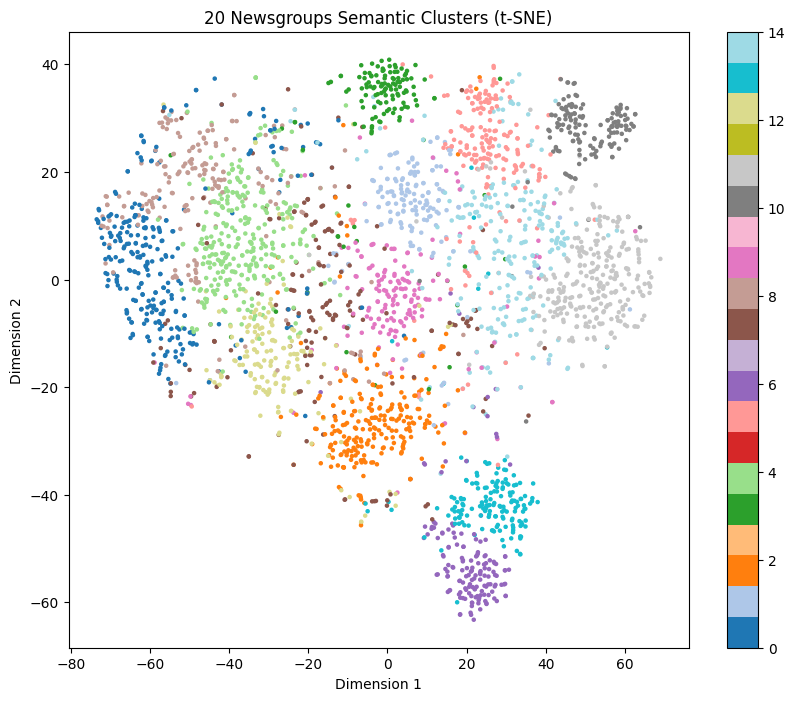

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

print("Loading embeddings...")
embeddings = np.load("../embeddings/embeddings.npy")

print("Loading cluster labels...")
clusters = np.load("../clustering_results/dominant_clusters.npy")

# Use subset because t-SNE is expensive
sample_size = 3000
embeddings_sample = embeddings[:sample_size]
clusters_sample = clusters[:sample_size]

print("Running t-SNE (this may take a few minutes)...")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca"
)

embeddings_2d = tsne.fit_transform(embeddings_sample)

print("Plotting clusters...")

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    embeddings_2d[:,0],
    embeddings_2d[:,1],
    c=clusters_sample,
    cmap="tab20",
    s=5
)

plt.title("20 Newsgroups Semantic Clusters (t-SNE)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.colorbar(scatter)

plt.show()

In [33]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

print("Loading documents...")
documents = np.load("../embeddings/documents.npy", allow_pickle=True)

print("Loading cluster assignments...")
clusters = np.load("../clustering_results/dominant_clusters.npy")

n_clusters = len(np.unique(clusters))

print("Clusters detected:", n_clusters)

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=10000
)

print("Computing TF-IDF...")
X = vectorizer.fit_transform(documents)

feature_names = np.array(vectorizer.get_feature_names_out())

for cluster_id in range(n_clusters):

    cluster_indices = np.where(clusters == cluster_id)[0]

    cluster_docs = X[cluster_indices]

    mean_tfidf = cluster_docs.mean(axis=0)

    top_indices = np.argsort(mean_tfidf.A1)[-10:]

    keywords = feature_names[top_indices]

    print("\nCluster", cluster_id)
    print("Top words:", ", ".join(keywords))

Loading documents...
Loading cluster assignments...
Clusters detected: 15
Computing TF-IDF...

Cluster 0
Top words: like, know, use, graphics, window, files, file, thanks, program, windows

Cluster 1
Top words: health, patients, people, like, know, don, disease, medical, msg, doctor

Cluster 2
Top words: good, ride, don, new, like, engine, just, cars, bike, car

Cluster 3
Top words: algorithm, escrow, use, nsa, keys, government, chip, clipper, encryption, key

Cluster 4
Top words: know, does, use, monitor, bus, video, thanks, scsi, drive, card

Cluster 5
Top words: weapons, law, koresh, government, don, batf, guns, people, fbi, gun

Cluster 6
Top words: runs, braves, think, players, hit, games, team, year, baseball, game

Cluster 7
Top words: ftp, information, like, email, does, phone, know, address, thanks, mail

Cluster 8
Top words: using, memory, running, mouse, disk, file, drive, dos, windows, problem

Cluster 9
Top words: think, just, like, launch, earth, moon, shuttle, nasa, orbi